# Цель проекта
Исследовательский анализ данных событий Яндекс Афиши

познакомиться с данными, проверить их корректность, провести предобработку, получив необходимый срез данных, выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

# Описание данных
final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных
order_id — уникальный идентификатор заказа.
user_id — уникальный идентификатор пользователя.
created_dt_msk — дата создания заказа (московское время).
created_ts_msk — дата и время создания заказа (московское время).
event_id — идентификатор мероприятия из таблицы events.
cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
age_limit — возрастное ограничение мероприятия.
currency_code — валюта оплаты, например rub для российских рублей.
device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
revenue — выручка от заказа.
service_name — название билетного оператора.
tickets_count — количество купленных билетов.
total — общая сумма заказа.

Второй датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.
event_id — уникальный идентификатор мероприятия.
event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
event_type_description — описание типа мероприятия.
event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
organizers — организаторы мероприятия.
region_name — название региона.
city_name — название города.
venue_id — уникальный идентификатор площадки.
venue_name — название площадки.
venue_address — адрес площадки.

Датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
nominal — номинал (100 тенге).
data — дата.
curs — курс тенге к рублю.
cdx — обозначение валюты (kzt).

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
try:
    df_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
except FileNotFoundError:
    df_orders = pd.read_csv('final_tickets_orders_df.csv')

try:
    df_events = pd.read_csv('/datasets/final_tickets_events_df.csv')
except FileNotFoundError:
    df_events = pd.read_csv('final_tickets_events_df.csv')

try:
    df_tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
except FileNotFoundError:
    df_tenge = pd.read_csv('final_tickets_tenge_df.csv')

In [3]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 3

In [4]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


In [5]:
df_tenge.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [6]:
# соединим датафреймы
df = df_orders.merge(df_events, on='event_id')

In [7]:
# переведем дату в формат даты
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

In [8]:
# переведем столбцы в формат даты
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

In [9]:
# соединим датафреймы
df = df.merge(df_tenge, left_on='created_dt_msk', right_on='data')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  str           
 2   created_dt_msk          290611 non-null  datetime64[us]
 3   created_ts_msk          290611 non-null  datetime64[us]
 4   event_id                290611 non-null  int64         
 5   cinema_circuit          290611 non-null  str           
 6   age_limit               290611 non-null  int64         
 7   currency_code           290611 non-null  str           
 8   device_type_canonical   290611 non-null  str           
 9   revenue                 290611 non-null  float64       
 10  service_name            290611 non-null  str           
 11  tickets_count           290611 non-null  int64         
 12  total                   290611 non-null  

- В данном датасете имеется 290611 строк и 24 столбцов.
- Пропуски наблюдаются только в столбце 'days_since_prev'.
- Следует перевести столбцы с датой и времени к нужному формату, а так же понизить разрядность во всех числовых столбцах

In [11]:
# убедимся, что пропуски только в столбце days_since_prev
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
data                          0
nominal                       0
curs                          0
cdx                           0
dtype: int64

In [12]:
# понижаем целые числа (int64 -> int32/int16/int8)
for col in df.select_dtypes(include=['integer']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# понижаем дробные числа (float64 -> float32)
for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

## Изучаем значения в ключевых столбцах

In [13]:
df['event_type_main'].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

In [14]:
df['event_type_description'].value_counts()

event_type_description
концерт                   112049
событие                    58605
спектакль                  50592
шоу                        13626
спорт                      12837
мюзикл                      9919
спортивное мероприятие      9074
балет                       5998
выставка                    5876
цирковое шоу                5327
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
подарок                        4
снегурочка                     3
рок-мюзикл                     1
Name: count, dtype: int64

In [15]:
df['region_name'].value_counts()

region_name
Каменевский регион          91058
Североярская область        44049
Широковская область         16457
Медовская область           13901
Озернинский край            10476
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: count, Length: 81, dtype: int64

In [16]:
df['city_name'].value_counts()

city_name
Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
                ...  
Карасуй             1
Дальнеград          1
Берёзовка           1
Дальнозелен         1
Травино             1
Name: count, Length: 352, dtype: int64

In [17]:
df['device_type_canonical'].value_counts()

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

In [18]:
# Переведем значения тенге в рубли для удобства вычислений
# Сначала копируем значения
df['revenue_rub'] = df['revenue']
df['total_rub'] = df['total']

# Обновляем значения только для тенге
mask = df['currency_code'] == 'kzt'
df.loc[mask, 'revenue_rub'] = df.loc[mask, 'revenue'] * df.loc[mask, 'curs'] / df.loc[mask, 'nominal']
df.loc[mask, 'total_rub'] = df.loc[mask, 'total'] * df.loc[mask, 'curs'] / df.loc[mask, 'nominal']

Изучаем значения количественных метрик

In [19]:
# Список колонок для анализа
metrics = ['revenue', 'tickets_count']

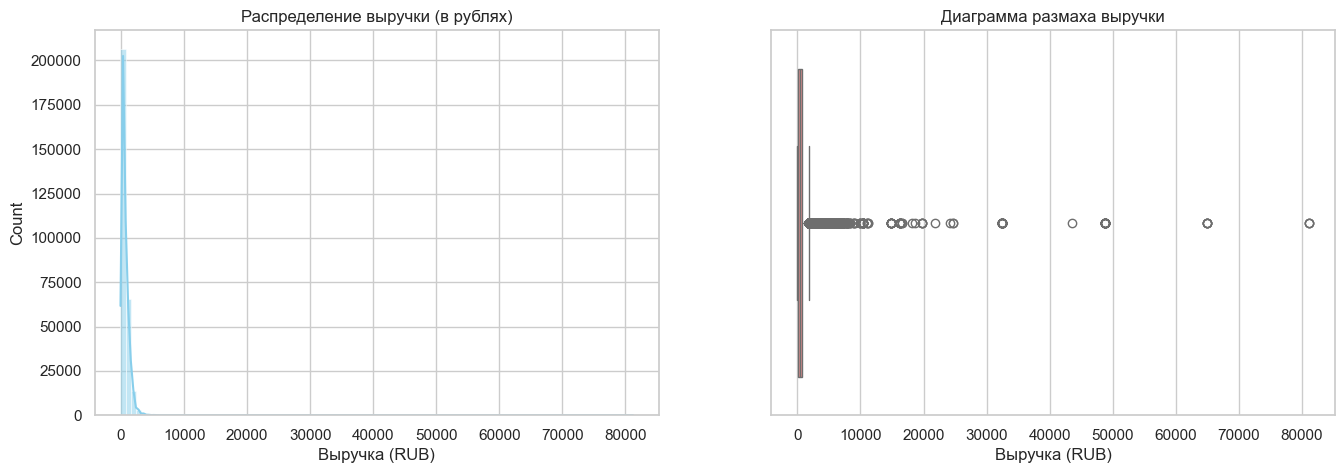

In [20]:
# Настройка стиля
sns.set_theme(style="whitegrid")

# Создаем фигуру с двумя графиками
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма распределения выручки в рублях
sns.histplot(df['revenue_rub'], bins=100, ax=ax[0], kde=True, color='skyblue')
ax[0].set_title('Распределение выручки (в рублях)')
ax[0].set_xlabel('Выручка (RUB)')

# Диаграмма размаха (Boxplot) для поиска выбросов
sns.boxplot(x=df['revenue_rub'], ax=ax[1], color='lightcoral')
ax[1].set_title('Диаграмма размаха выручки')
ax[1].set_xlabel('Выручка (RUB)')

plt.show()

In [21]:
# Рассчитываем 99-й процентиль
revenue_limit = df['revenue_rub'].quantile(0.99)
tickets_limit = df['tickets_count'].quantile(0.99)

print(f"Порог для выручки (99%): {revenue_limit:.2f} руб.")
print(f"Порог для билетов (99%): {tickets_limit:.0f} шт.")

# Оставляем только те данные, которые входят в 99%
df_clean = df[(df['revenue_rub'] <= revenue_limit) & (df['tickets_count'] <= tickets_limit)].copy()

print(f"Размер датасета до очистки: {len(df)}")
print(f"Размер датасета после очистки: {len(df_clean)}")

Порог для выручки (99%): 2628.42 руб.
Порог для билетов (99%): 6 шт.
Размер датасета до очистки: 290611
Размер датасета после очистки: 287606


In [22]:
# Сравнение ключевых статистик
print("Статистика выручки в рублях:")
print(df_clean['revenue_rub'].describe())

Статистика выручки в рублях:
count    287606.000000
mean        517.791295
std         511.874110
min         -90.760000
25%         111.690000
50%         343.700000
75%         788.630000
max        2628.421657
Name: revenue_rub, dtype: float64


In [23]:
# Считаем количество отрицательных значений
negative_revenue = df_clean[df_clean['revenue_rub'] < 0]
negative_tickets = df[df['tickets_count'] < 0]

print(f"Строк с отрицательной выручкой: {len(negative_revenue)}")
print(f"Строк с отрицательными билетами: {len(negative_tickets)}")

Строк с отрицательной выручкой: 381
Строк с отрицательными билетами: 0


In [24]:
# Оставляем только корректные транзакции
df_clean = df_clean[df_clean['revenue_rub'] > 0]

In [25]:
print("Статистика выручки в рублях:")
print(df_clean['revenue_rub'].describe())

Статистика выручки в рублях:
count    281705.000000
mean        528.641070
std         511.630946
min           0.020000
25%         122.610000
50%         358.080000
75%         797.640000
max        2628.421657
Name: revenue_rub, dtype: float64


In [26]:
df = df_clean

In [27]:
# проверяем явные дубликаты
df.duplicated().sum()

np.int64(0)

In [28]:
# проверяем неявные дубликаты
# Список столбцов, определяющих уникальность транзакции (без учета order_id)
duplicate_criteria = [
    'user_id', 
    'event_id', 
    'created_ts_msk', 
    'tickets_count', 
    'revenue_rub', 
    'device_type_canonical'
]

# Ищем дубликаты по этим критериям
implicit_dupes = df[df.duplicated(subset=duplicate_criteria, keep=False)]

print(f"Найдено строк, похожих на скрытые дубликаты: {len(implicit_dupes)}")
print(implicit_dupes.sort_values(by=['user_id', 'created_ts_msk']).head(10))

Найдено строк, похожих на скрытые дубликаты: 75
       order_id          user_id created_dt_msk      created_ts_msk  event_id  \
11759   1123983  06eb7897f65b433     2024-08-13 2024-08-13 16:31:07    183706   
11760   1123867  06eb7897f65b433     2024-08-13 2024-08-13 16:31:07    183706   
26868   1930705  0dc525d7bacbb0d     2024-07-31 2024-07-31 13:26:11    393430   
26870   1930763  0dc525d7bacbb0d     2024-07-31 2024-07-31 13:26:11    393430   
53680   1935113  206ea45ec11d478     2024-10-29 2024-10-29 16:46:54    442183   
53682   1935171  206ea45ec11d478     2024-10-29 2024-10-29 16:46:54    442183   
57173    160922  2564e3703075008     2024-10-30 2024-10-30 10:04:15    589005   
57176    160893  2564e3703075008     2024-10-30 2024-10-30 10:04:15    589005   
68162   3326185  2ecf0a4e24cae13     2024-10-17 2024-10-17 15:25:33    481392   
68163   3326272  2ecf0a4e24cae13     2024-10-17 2024-10-17 15:25:33    481392   

      cinema_circuit  age_limit currency_code device_type_ca

In [29]:
# Удаляем неявные дубликаты
df = df.drop_duplicates(subset=duplicate_criteria, keep='first').reset_index(drop=True)

print(f"Очистка завершена. Текущее количество строк: {len(df)}")

Очистка завершена. Текущее количество строк: 281666


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 281666 entries, 0 to 281665
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281666 non-null  int32         
 1   user_id                 281666 non-null  str           
 2   created_dt_msk          281666 non-null  datetime64[us]
 3   created_ts_msk          281666 non-null  datetime64[us]
 4   event_id                281666 non-null  int32         
 5   cinema_circuit          281666 non-null  str           
 6   age_limit               281666 non-null  int8          
 7   currency_code           281666 non-null  str           
 8   device_type_canonical   281666 non-null  str           
 9   revenue                 281666 non-null  float64       
 10  service_name            281666 non-null  str           
 11  tickets_count           281666 non-null  int8          
 12  total                   281666 non-null  

In [31]:
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

In [32]:
df['month'] = df['created_dt_msk'].dt.month

In [33]:
# Создаем словарь соответствия
season_map = {
    1: 'зима', 2: 'зима', 12: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}

# Применяем маппинг
df['season'] = df['month'].map(season_map)

# Проверим результат
print(df[['month', 'season']].drop_duplicates().sort_values('month'))

   month season
9      6   лето
1      7   лето
0      8   лето
7      9  осень
2     10  осень


In [34]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_address,data,nominal,curs,cdx,revenue_rub,total_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,"алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.697201,kzt,1521.94,10870.99,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,"алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.341900,kzt,289.45,2067.51,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,"алл. Юбилейная, д. 5/6",2024-10-06,100,19.647499,kzt,1258.57,13984.16,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,"алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.500999,kzt,8.49,212.28,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,"ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.664801,kzt,1390.41,10695.43,463.4700,10,осень


In [35]:
# понижаем целые числа (int64 -> int32/int16/int8)
for col in df.select_dtypes(include=['integer']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# понижаем дробные числа (float64 -> float32)
for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 281666 entries, 0 to 281665
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281666 non-null  int32         
 1   user_id                 281666 non-null  str           
 2   created_dt_msk          281666 non-null  datetime64[us]
 3   created_ts_msk          281666 non-null  datetime64[us]
 4   event_id                281666 non-null  int32         
 5   cinema_circuit          281666 non-null  str           
 6   age_limit               281666 non-null  int8          
 7   currency_code           281666 non-null  str           
 8   device_type_canonical   281666 non-null  str           
 9   revenue                 281666 non-null  float32       
 10  service_name            281666 non-null  str           
 11  tickets_count           281666 non-null  int8          
 12  total                   281666 non-null  

## Промежуточный вывод
- Была проведена загрузка данных и знакомство с ними
- При первом объединении таблиц было 290611 строк и 28 столбцов, после предобработки данных стало 281666 строк и 33 столбца.
- Были добавлены столбцы с выручкой и общей суммой в рублях, доход с одного билета в рублях, номер месяца и сезон покупки билета
- Проверили пропуски, были только в столбце days_since_prev
- Были удалены неявные дубликаты с разными номерами заказами
- Преобразовали типы данных с датой, так же понизили разрядность числовых значений

# Исследовательский анализ данных

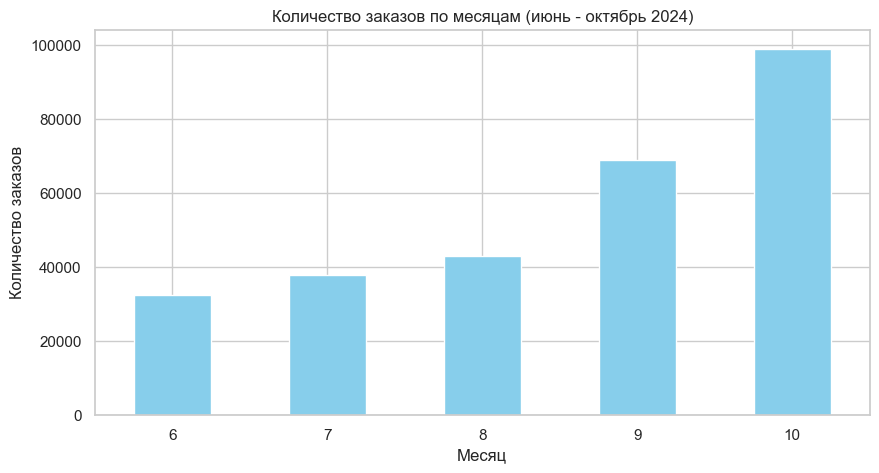

In [37]:
# Группируем по месяцам и считаем количество уникальных заказов
monthly_orders = df.groupby('month')['order_id'].count()

# Визуализация
plt.figure(figsize=(10, 5))
monthly_orders.plot(kind='bar', color='skyblue')
plt.title('Количество заказов по месяцам (июнь - октябрь 2024)')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation=0)
plt.show()

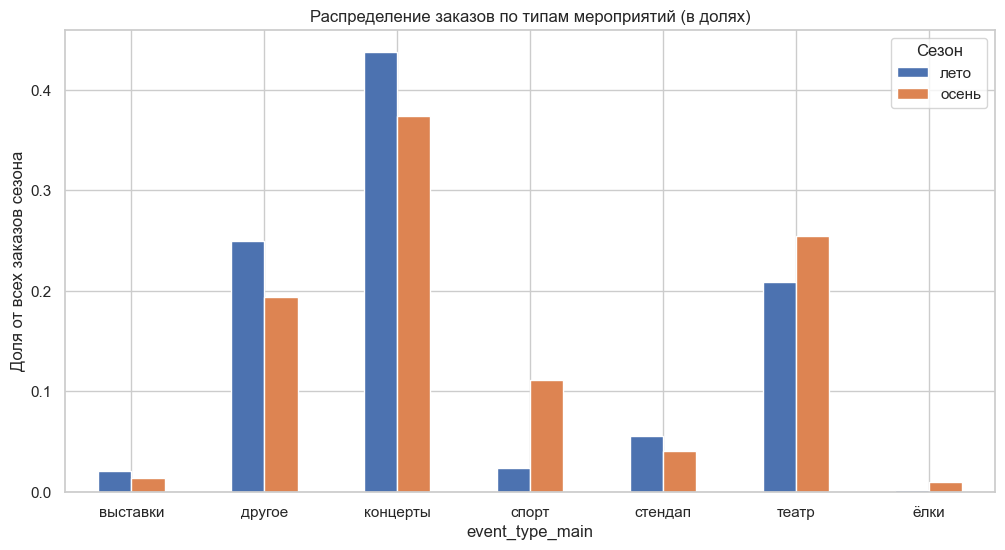

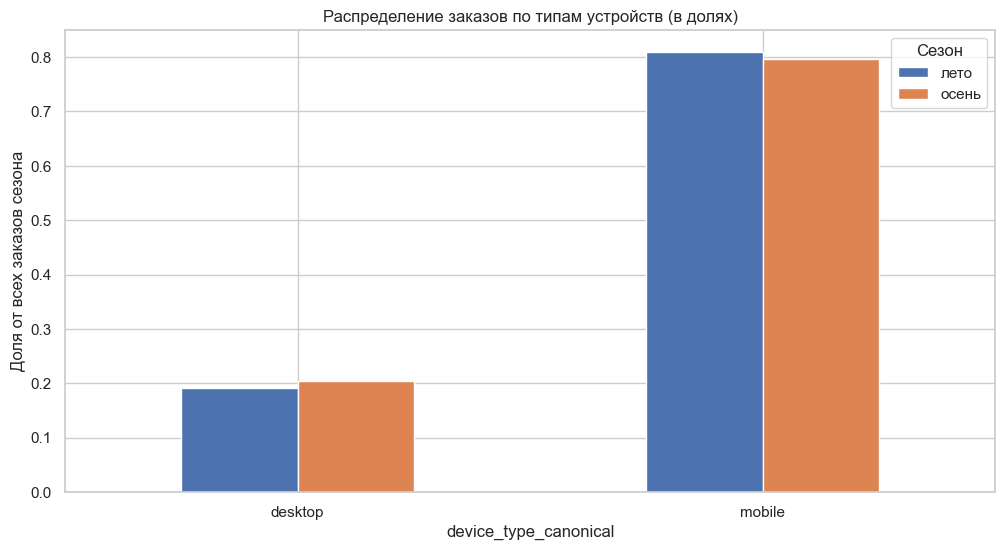

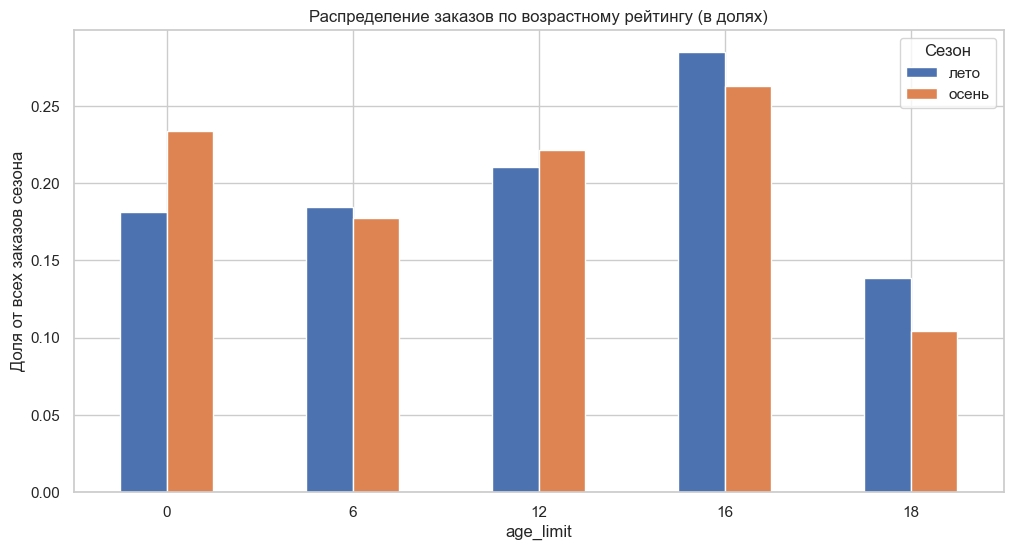

In [38]:
def plot_seasonal_share(column, title):
    # Создаем таблицу сопряженности (counts)
    seasonal_counts = pd.crosstab(df[column], df['season'])
    
    # Переводим в доли (проценты от общего количества заказов в этом сезоне)
    seasonal_shares = seasonal_counts.div(seasonal_counts.sum(axis=0), axis=1)
    
    # Визуализация
    seasonal_shares.plot(kind='bar', figsize=(12, 6), rot=0)
    plt.title(f'Распределение заказов по {title} (в долях)')
    plt.ylabel('Доля от всех заказов сезона')
    plt.legend(title='Сезон')
    plt.show()

# Запускаем для трех разрезов
plot_seasonal_share('event_type_main', 'типам мероприятий')
plot_seasonal_share('device_type_canonical', 'типам устройств')
plot_seasonal_share('age_limit', 'возрастному рейтингу')

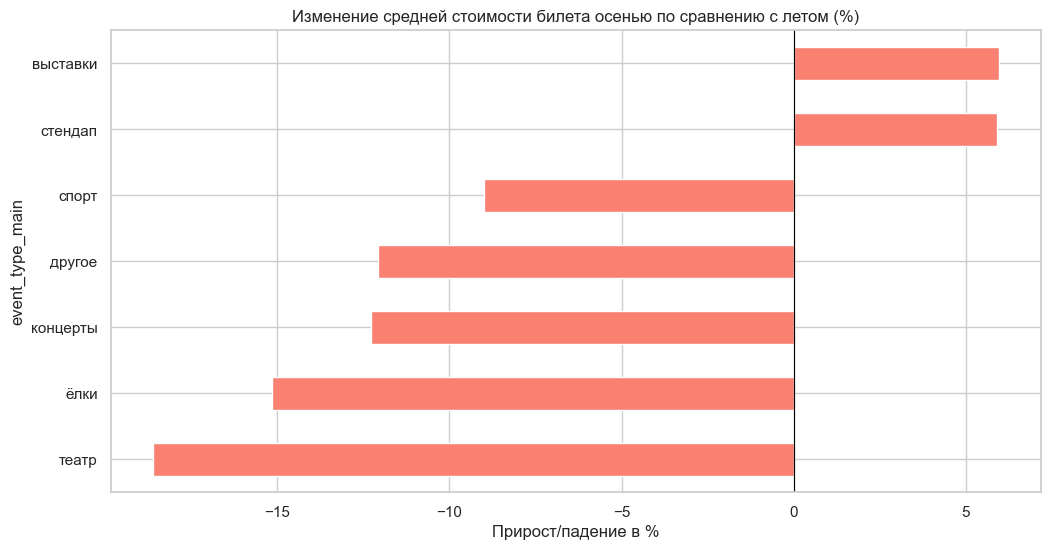

In [39]:
# 1. Считаем среднюю стоимость билета по категориям и сезонам
ticket_prices = df.pivot_table(
    index='event_type_main', 
    columns='season', 
    values='one_ticket_revenue_rub', 
    aggfunc='mean'
)

# 2. Считаем относительное изменение (осень vs лето) в процентах
ticket_prices['change_pct'] = ((ticket_prices['осень'] - ticket_prices['лето']) / ticket_prices['лето']) * 100

# 3. Визуализация изменений
plt.figure(figsize=(12, 6))
ticket_prices['change_pct'].sort_values().plot(kind='barh', color='salmon')
plt.title('Изменение средней стоимости билета осенью по сравнению с летом (%)')
plt.xlabel('Прирост/падение в %')
plt.axvline(0, color='black', linewidth=0.8) # Линия нуля для наглядности
plt.show()

1. От июня к ноябрю 2024 года у нас фиксируется стабильный рост количества проданных билетов. Если в июне отметка находится в районе 30 тыс проданных билетов то в конце периода в октябре их уже почти 100 тыс
2. Можно отметить, что людям больше нравится ходить на выставки, стендап, концерты в летнее время, либо такие мероприятия проходят преимущественно в летнее время + есть возможность проводить их на открытом воздухе. Театры и спортивные мероприятия напротив, имеют больше спрос в осеннее время (сезоны в спорте обычно начинаются в конце августа - начале сентября), с наступлением холодов люди предпочитают больше проводить время в закрытых помещениях
3. Мобильные телефоны так же оставляют доминирующую позицию по типу устройств, около 80% транзакций проходят через телефон, в то время как через компьютер примерно 20%
4. Осенью заметно выросла доля мероприятий с рейтингом "0+" (с 18% до 23%), что указывает на рост спроса на семейный досуг. Доля «взрослых» мероприятий (18+) снизилась
5. Анализ средней выручки с одного билета показал интересную тенденцию: несмотря на рост количества заказов, средняя стоимость одного билета в большинстве категорий снизилась:
Самое сильное падение цены зафиксировано в категориях Театр (-18.6%) и Ёлки (-15.2%).
Стоимость билетов на концерты также снизилась на 12.3%.
Небольшой рост стоимости показали только Стендап (+5.9%) и Выставки (+5.9%).

In [40]:
# оставим данные для осени
autumn_df = df[df['season'] == 'осень'].copy()

In [41]:
# создаем сводную таблицу по дням
daily_stats = autumn_df.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()
daily_stats

,created_dt_msk,total_orders,dau,avg_ticket_price
0,2024-09-01,1318,556,203.667419
1,2024-09-02,1370,571,190.847824
2,2024-09-03,5091,776,80.866287
3,2024-09-04,1758,683,179.864883
4,2024-09-05,1937,739,190.393219
...,...,...,...,...
56,2024-10-27,2845,1033,188.146286
57,2024-10-28,2837,985,171.181229
58,2024-10-29,2835,999,178.608963
59,2024-10-30,2927,1040,183.412888


In [42]:
# Рассчитываем среднее количество заказов на одного пользователя
daily_stats['orders_per_user'] = daily_stats['total_orders'] / daily_stats['dau']

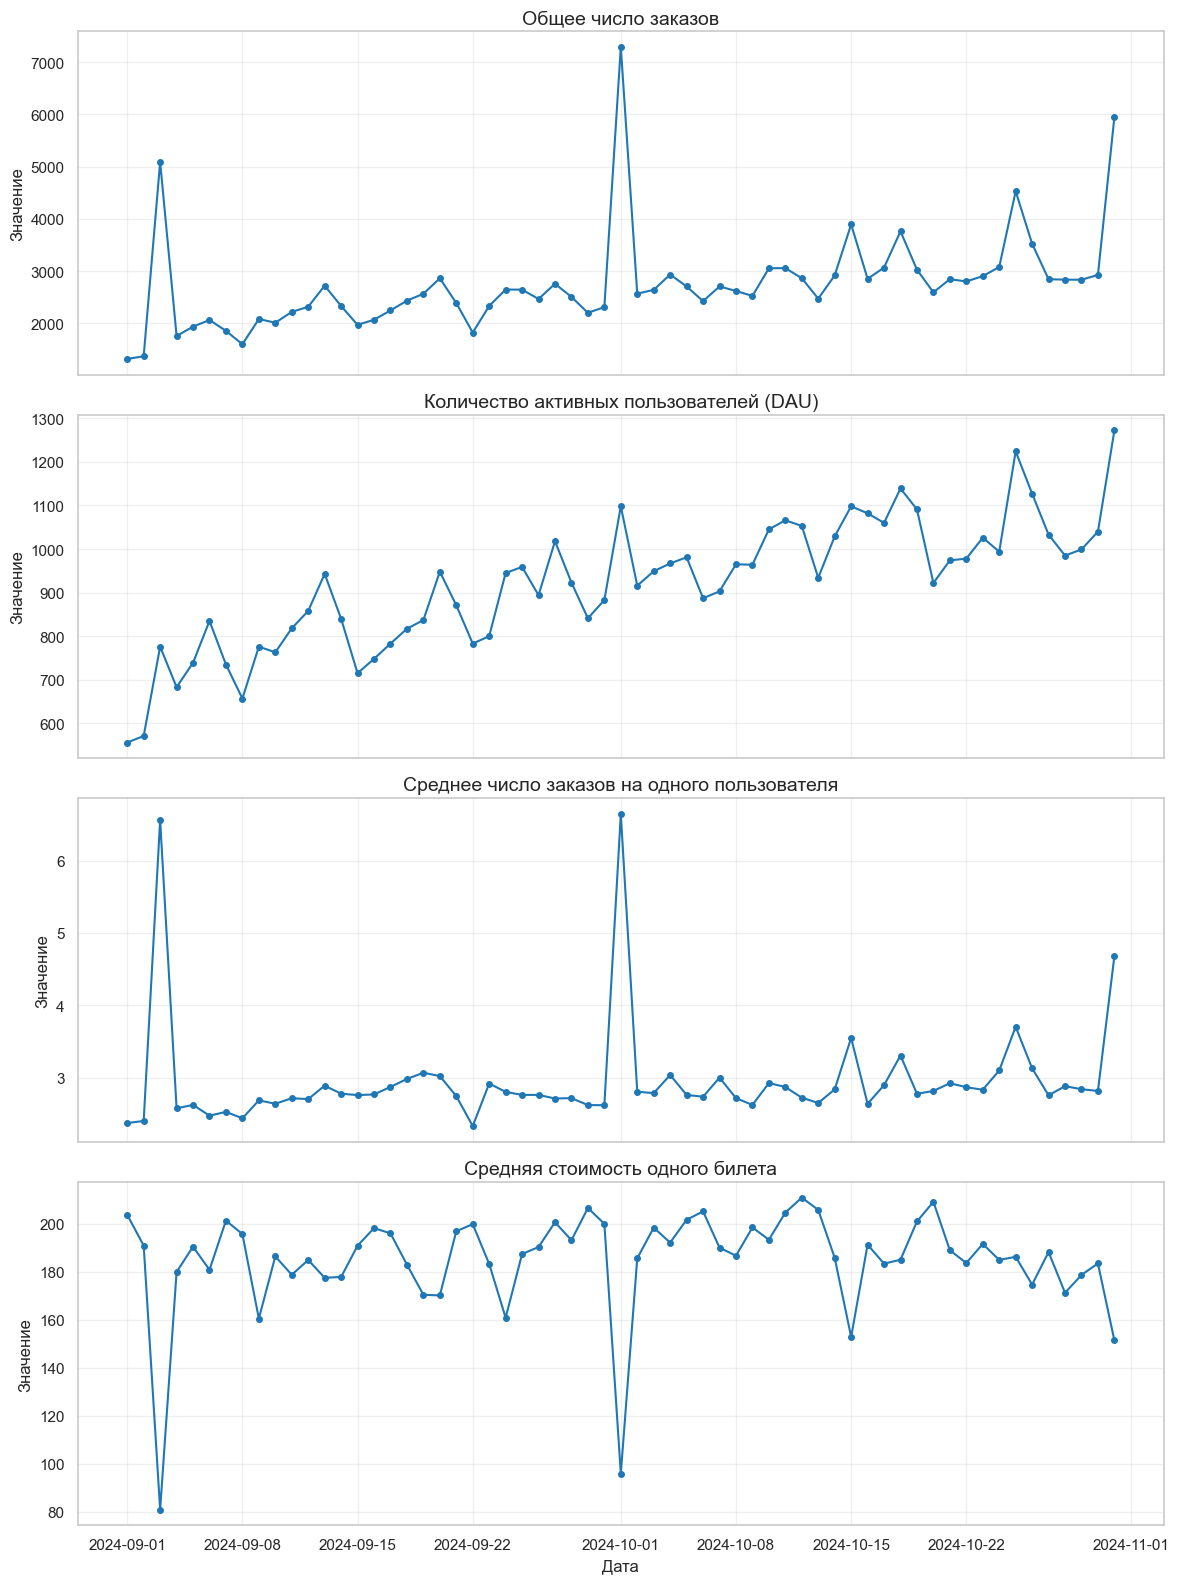

In [43]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

metrics = [
    ('total_orders', 'Общее число заказов'),
    ('dau', 'Количество активных пользователей (DAU)'),
    ('orders_per_user', 'Среднее число заказов на одного пользователя'),
    ('avg_ticket_price', 'Средняя стоимость одного билета')
]

for i, (col, title) in enumerate(metrics):
    axes[i].plot(daily_stats['created_dt_msk'], daily_stats[col], marker='o', linestyle='-', markersize=4, color='tab:blue')
    axes[i].set_title(title, fontsize=14)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylabel('Значение')

plt.xlabel('Дата')
plt.tight_layout()
plt.show()

In [44]:
# Изучение недельной цикличности
# Добавляем день недели и признак выходного
autumn_df['day_of_week'] = autumn_df['created_dt_msk'].dt.dayofweek
autumn_df['is_weekend'] = autumn_df['day_of_week'].isin([5, 6]).map({True: 'Выходной', False: 'Будни'})

In [45]:
# Среднее количество заказов в день для будней и выходных
weekend_comparison = autumn_df.groupby('is_weekend').agg(
    total_orders=('order_id', 'count'),
    unique_days=('created_dt_msk', 'nunique')
)
weekend_comparison['avg_orders_per_day'] = weekend_comparison['total_orders'] / weekend_comparison['unique_days']

print("Сравнение активности (среднее число заказов в день):")
print(weekend_comparison[['avg_orders_per_day']])

Сравнение активности (среднее число заказов в день):
            avg_orders_per_day
is_weekend                    
Будни              2898.386364
Выходной           2379.882353


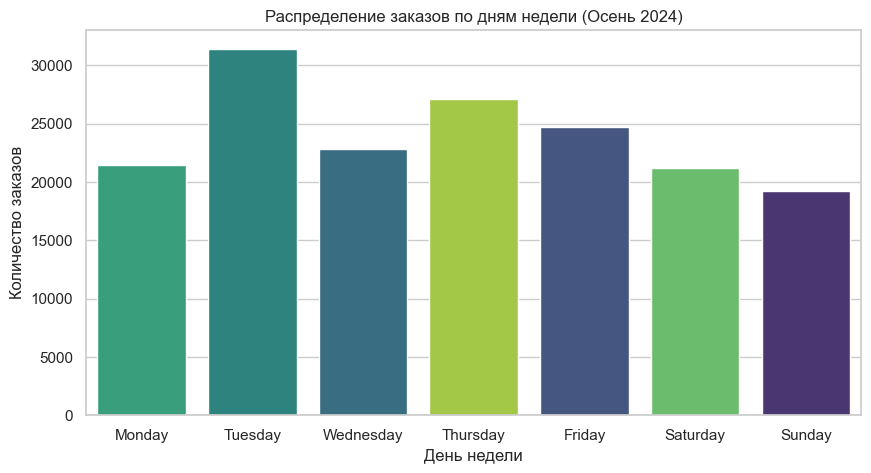

In [46]:
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Названия дней недели для графика
autumn_df['day_name'] = autumn_df['created_dt_msk'].dt.day_name()
sns.countplot(
    data=autumn_df, 
    x='day_name', 
    order=day_order, 
    palette='viridis', 
    hue='day_name', 
    legend=False
)
plt.title('Распределение заказов по дням недели (Осень 2024)')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.show()

- В течение осени наблюдается восходящий тренд как в общем количестве заказов, так и в DAU. Пиковые значения приходятся на октябрь, что подтверждает рост интереса к мероприятиям в середине сезона.
- DAU и общее число заказов коррелируют между собой, что логично: рост выручки обеспечивается притоком новых пользователей, а не увеличением частоты покупок старыми.
- Среднее число заказов на пользователя остается стабильно низким (близким к 1.0–1.2), что означает, что пользователи осенью редко совершают несколько покупок в один и тот же день.
- Средняя стоимость билета демонстрирует колебания, но не имеет ярко выраженного тренда к росту.

- Анализ по дням недели показывает, что наиболее активными днями являются вторник и четверг. В выходные (суббота и воскресенье) активность пользователей, как ни странно, снижается.
- Среднее число заказов в день в будни значительно выше, чем в выходные (примерно 2900 против 2380 по средним показателям).
- Это может указывать на то, что пользователи предпочитают планировать и бронировать свой досуг заранее (в рабочее время), тогда как в сами выходные они уже посещают мероприятия и реже заходят в сервис для новых покупок.

In [47]:
# Региональный анализ
# Группируем по регионам: уникальные мероприятия и общее число заказов
region_stats = autumn_df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count')
).reset_index()

In [48]:
# Расчет долей от общего итога по осени
total_autumn_events = autumn_df['event_id'].nunique()
total_autumn_orders = len(autumn_df)

In [49]:
region_stats['event_share'] = region_stats['unique_events'] / total_autumn_events
region_stats['order_share'] = region_stats['total_orders'] / total_autumn_orders

In [50]:
# Топ-10 регионов по разнообразию мероприятий
top_regions = region_stats.sort_values(by='unique_events', ascending=False).head(10)
print("Топ-10 регионов по разнообразию мероприятий:")
print(top_regions[['region_name', 'unique_events', 'total_orders', 'event_share', 'order_share']])

Топ-10 регионов по разнообразию мероприятий:
                region_name  unique_events  total_orders  event_share  \
23       Каменевский регион           3897         46598     0.247083   
59     Североярская область           2594         20571     0.164469   
75      Широковская область            794          8645     0.050342   
56     Светополянский округ            755          4750     0.047870   
51      Речиновская область            529          3565     0.033540   
60     Серебринская область            456          4470     0.028912   
76      Яблоневская область            431          4195     0.027327   
67     Тепляковская область            419          2485     0.026566   
11     Горицветская область            406          3230     0.025742   
63  Солнечноземская область            401          4197     0.025425   

    order_share  
23     0.277391  
59     0.122456  
75     0.051462  
56     0.028276  
51     0.021222  
60     0.026609  
76     0.024972  
67     

In [51]:
# Анализ билетных партнёров
# Группируем по партнёрам
partner_stats = autumn_df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    processed_orders=('order_id', 'count'),
    total_revenue_rub=('revenue_rub', 'sum')
).reset_index()

In [52]:
# Расчет долей по заказам и выручке
partner_stats['order_share'] = partner_stats['processed_orders'] / total_autumn_orders
partner_stats['revenue_share'] = partner_stats['total_revenue_rub'] / autumn_df['revenue_rub'].sum()

In [53]:
# Наиболее активные партнёры (по количеству заказов)
top_partners = partner_stats.sort_values(by='processed_orders', ascending=False)
print("\nСтатистика по билетным партнёрам (Топ):")
print(top_partners.head(10)[['service_name', 'unique_events', 'processed_orders', 'total_revenue_rub', 'order_share']])


Статистика по билетным партнёрам (Топ):
          service_name  unique_events  processed_orders  total_revenue_rub  \
3   Билеты без проблем           2819             32098       1.245650e+07   
21         Лови билет!           3586             25718       1.041227e+07   
5        Билеты в руки           2445             25536       7.618874e+06   
24           Мой билет           1002             19400       1.084190e+07   
25             Облачко           1409             15478       1.061105e+07   
22       Лучшие билеты           1377             12342       1.672814e+06   
8       Весь в билетах            600              9426       9.378864e+06   
26           Прачечная            728              5798       2.548310e+06   
30         Тебе билет!            858              3765       2.181788e+06   
34              Яблоко            537              3473       2.763332e+06   

    order_share  
3      0.191074  
21     0.153095  
5      0.152012  
24     0.115485  
25     0.0

- Каменевский регион является абсолютным лидером как по разнообразию мероприятий (почти 25% от всех уникальных событий осени), так и по количеству заказов (27.7%). Это ключевой рынок для сервиса.
- На втором месте — Североярская область (16.5% событий и 12.3% заказов).
- Остальные регионы (Широковская, Светополянская области) имеют значительно меньшие доли (около 5% и ниже). Это говорит о высокой концентрации рынка в двух-трех крупнейших регионах.

- Среди билетных операторов нет одного монополиста, но выделяется «большая пятерка»: «Билеты без проблем», «Лови билет!», «Билеты в руки», «Мой билет» и «Облачко».
- Самый широкий охват мероприятий у партнёра «Лови билет!» (3586 уникальных событий), однако по числу заказов и выручке лидирует «Билеты без проблем» (19.1% заказов).
- Интересно, что партнёр «Мой билет», имея в 3.5 раза меньше уникальных мероприятий, чем лидер, генерирует сопоставимую выручку (доля рынка по выручке ~13.2%). Это может означать, что данный партнёр работает с более дорогими или эксклюзивными событиями.

## Статистический анализ данных

Прежде чем приступать к тестам, подготовим "чистые группы", где данные количественные, выборки независимые (выделим пользователей, которые пользуются только одним устройством), у данных имеется ассиметричное распределение с длинными хвостами, что делает невозможным использование t-теста Стьюдента, в группах разный объем выборок

In [54]:
# 1. Выделяем пользователей по типам устройств
user_devices = autumn_df.groupby('user_id')['device_type_canonical'].nunique()
pure_users = user_devices[user_devices == 1].index

In [55]:
# Оставляем только "чистых" пользователей
df_pure = autumn_df[autumn_df['user_id'].isin(pure_users)]

In [56]:
# Формируем группы для теста 1 (Кол-во заказов)
orders_by_user = df_pure.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
mobile_orders = orders_by_user[orders_by_user['device_type_canonical'] == 'mobile']['order_id']
desktop_orders = orders_by_user[orders_by_user['device_type_canonical'] == 'desktop']['order_id']

# 3. Формируем группы для теста 2 (Время между заказами)
mobile_time = df_pure[(df_pure['device_type_canonical'] == 'mobile') & (df_pure['days_since_prev'].notna())]['days_since_prev']
desktop_time = df_pure[(df_pure['device_type_canonical'] == 'desktop') & (df_pure['days_since_prev'].notna())]['days_since_prev']

Для проверки гипотез используем критерий Манна-Уитни так как: данные не распределены нормально, присутствуют значительные выбросы, дисперсии в группах не равны, а размер выборок сильно отличается. Критерий Манна-Уитни сравнивает не средние значения, а ранги, что делает его устойчивым к экстремальным значениям.

In [57]:
# зафиксируем значения до тестов
print(f"Среднее заказов (Mobile): {mobile_orders.mean():.2f}, Медиана: {mobile_orders.median()}")
print(f"Среднее заказов (Desktop): {desktop_orders.mean():.2f}, Медиана: {desktop_orders.median()}")

Среднее заказов (Mobile): 2.87, Медиана: 2.0
Среднее заказов (Desktop): 1.97, Медиана: 1.0


In [58]:
# Настройки теста
alpha = 0.05

# Гипотеза 1: Количество заказов
# H0: Распределения количества заказов в группах мобильных и десктоп-пользователей идентичны.
# H1: Количество заказов у пользователей мобильных устройств выше.

stat1, p1 = stats.mannwhitneyu(mobile_orders, desktop_orders, alternative='greater')

# Гипотеза 2: Время между заказами
# H0: Распределения интервалов между заказами в группах идентичны.
# H1: Интервалы между заказами у мобильных пользователей больше.

stat2, p2 = stats.mannwhitneyu(mobile_time, desktop_time, alternative='greater')

print(f"Результат теста 1 (Заказы): p-value = {p1:.4f}")
print(f"Результат теста 2 (Время): p-value = {p2:.4f}")

Результат теста 1 (Заказы): p-value = 0.0000
Результат теста 2 (Время): p-value = 0.0000


Гипотеза 1. Результат p-value < 0.05. Мы отвергаем нулевую гипотезу. Статистический тест подтвердил, что пользователи мобильных устройств в среднем совершают больше заказов на одного человека, чем пользователи десктопов. Это может свидетельствовать о более высокой лояльности или удобстве интерфейса мобильного приложения для регулярных покупок
Гипотеза 2. Результат p-value < 0.05. Мы отвергаем нулевую гипотезу. Статистически значимая разница подтверждена: у пользователей мобильных устройств время между заказами выше.
Несмотря на то, что мобильные пользователи делают больше заказов в сумме, они делают их реже (с большими перерывами). Это может означать, что десктопные пользователи — это узкая группа, совершающая быстрые «серийные» покупки (например, бронирование на компанию в несколько заходов), в то время как мобильные пользователи покупают билеты на протяжении всего сезона, но с более размеренным ритмом

# Общий вывод и рекомендации
## Информация о данных
### Для анализа использовались данные о бронировании билетов за период с 1 июня по 31 октября 2024 года. В ходе работы была проведена предобработка:
- Выручка в тенге конвертирована в рубли по ежедневному курсу.
- Данные очищены от отрицательных значений, полных и неявных дубликатов.
- Удалены аномальные выбросы по 99-му процентилю для стабилизации средних показателей.
## Основные результаты анализа
- Сезонный всплеск: К октябрю количество заказов выросло в 3 раза по сравнению с июнем (с 32 до 99 тыс. заказов).
- Смена интересов: Осенью пользователи стали реже выбирать концерты (доля упала с 43% до 37%) в пользу театральных постановок (рост до 25%) и спортивных мероприятий (рост с 2% до 11%). Также зафиксирован рост интереса к семейному досугу (категория «0+»).
- Стоимость: Средний чек и стоимость одного билета осенью снизились (в театре на 18%, в концертах на 12%). Это говорит о том, что рост выручки осенью обеспечен «массовостью» и доступностью билетов, а не ростом цен.
- Лидеры: Каменевский регион и Североярская область генерируют более 40% всех заказов. Пятерка крупнейших операторов (лидер — «Билеты без проблем») контролирует более 70% рынка
## Результаты проверки гипотез
Статистический анализ (тест Манна-Уитни, p-value < 0.05) подтвердил:
- Пользователи мобильных устройств более активны: они совершают в среднем больше заказов за сезон, чем пользователи десктопов.
- При этом у мобильных пользователей значительно выше интервал между покупками. Они возвращаются в сервис чаще, но делают это более размеренно.
## Рекомендации
- Стимулирование повторных продаж: Поскольку мобильные пользователи лояльны, но делают длинные паузы между заказами, необходимо внедрить систему персональных рекомендаций и push-уведомлений, чтобы сократить время между покупками.
- Фокус на семейный контент: Учитывая рост доли категории «0+» и «6+» осенью, стоит расширить пул партнёров, предлагающих детские спектакли и выставки в регионах-лидерах.
- Региональное развитие: Высокая концентрация заказов в двух регионах указывает на потенциал роста в остальных областях. Стоит проанализировать, почему в Широковской или Светополянской областях при наличии мероприятий доля заказов остается низкой.
- Технический мониторинг: Обнаруженные неявные дубликаты (заказы в ту же секунду) сигнализируют о необходимости технического аудита процесса оплаты, чтобы избежать двойных списаний у пользователей.